## In this notebook, we will show how to read DE features with python

- Author: Wei Liu
- Affiliation: [BCMI lab, Shanghai Jiao Tong University, Shanghai, China](http://bcmi.sjtu.edu.cn)
- Date: May, 11, 2021

In [33]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

# check the version of these modules
print(np.__version__)
print(pickle.format_version)

2.3.2
4.0


In [34]:
# load DE features named '1_123.npz'

data_npz = np.load('1_123.npz')
print(data_npz.files)

['data', 'label']


In [35]:
# get data and label
# ** both 'data' and 'label' are pickled dict **

data = pickle.loads(data_npz['data'])
label = pickle.loads(data_npz['label'])

print(data.keys())
print(label.keys())

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44])
dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44])


In [36]:
# As we can see, there are 45 keys in both 'data' and 'label'.
# Each participant took part in our experiments for 3 sessions, and he/she watched 15 movie clips (i.e. 15 trials) during each session.
# Therefore, we could extract 3 * 15 = 45 DE feature matrices.

# The key indexes [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14] belong to Session 1.
# The key indexes [15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29] belong to Session 2.
# The key indexes [30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44] belong to Session 3.

# We will print the emotion labels for each trial.
label_dict = {0:'Disgust', 1:'Fear', 2:'Sad', 3:'Neutral', 4:'Happy'}
for i in range(45):
    print('Session {} -- Trial {} -- EmotionLabel : {}'.format(i//15+1, i%15+1, label_dict[label[i][0]]))

Session 1 -- Trial 1 -- EmotionLabel : Happy
Session 1 -- Trial 2 -- EmotionLabel : Fear
Session 1 -- Trial 3 -- EmotionLabel : Neutral
Session 1 -- Trial 4 -- EmotionLabel : Sad
Session 1 -- Trial 5 -- EmotionLabel : Disgust
Session 1 -- Trial 6 -- EmotionLabel : Happy
Session 1 -- Trial 7 -- EmotionLabel : Fear
Session 1 -- Trial 8 -- EmotionLabel : Neutral
Session 1 -- Trial 9 -- EmotionLabel : Sad
Session 1 -- Trial 10 -- EmotionLabel : Disgust
Session 1 -- Trial 11 -- EmotionLabel : Happy
Session 1 -- Trial 12 -- EmotionLabel : Fear
Session 1 -- Trial 13 -- EmotionLabel : Neutral
Session 1 -- Trial 14 -- EmotionLabel : Sad
Session 1 -- Trial 15 -- EmotionLabel : Disgust
Session 2 -- Trial 1 -- EmotionLabel : Sad
Session 2 -- Trial 2 -- EmotionLabel : Fear
Session 2 -- Trial 3 -- EmotionLabel : Neutral
Session 2 -- Trial 4 -- EmotionLabel : Disgust
Session 2 -- Trial 5 -- EmotionLabel : Happy
Session 2 -- Trial 6 -- EmotionLabel : Happy
Session 2 -- Trial 7 -- EmotionLabel : Disgus

The above emotion labels should be the same as labels in file "emotion_label_and_stimuli_order.xlsx"

In [37]:
# How to extract each frequency band from DE features
# The DE features have shape (18, 310) where:
# - 18 = number of EEG channels
# - 310 = 5 frequency bands × 62 time segments

# Get data for trial 0 as example
trial_data = data[0]
print(f"Original data shape: {trial_data.shape}")

# Each frequency band has 62 features (time segments)
# The data is organized as: [delta, theta, alpha, beta, gamma]
band_size = 62

# Extract each frequency band
delta_band = trial_data[:, 0:62]          # 1-4 Hz
theta_band = trial_data[:, 62:124]        # 4-8 Hz  
alpha_band = trial_data[:, 124:186]       # 8-14 Hz
beta_band = trial_data[:, 186:248]        # 14-31 Hz
gamma_band = trial_data[:, 248:310]       # 31-50 Hz

print(f"Delta band shape: {delta_band.shape}")
print(f"Theta band shape: {theta_band.shape}")
print(f"Alpha band shape: {alpha_band.shape}")
print(f"Beta band shape: {beta_band.shape}")
print(f"Gamma band shape: {gamma_band.shape}")

# Example: Get alpha band features for all channels
print(f"\nAlpha band features for channel 0 (first 10 time segments):")
print(alpha_band[0, :10])

Original data shape: (18, 310)
Delta band shape: (18, 62)
Theta band shape: (18, 62)
Alpha band shape: (18, 62)
Beta band shape: (18, 62)
Gamma band shape: (18, 62)

Alpha band features for channel 0 (first 10 time segments):
[6.65943599 7.2346458  5.69707339 5.68279517 4.87481431 4.28817979
 5.99475326 4.3029586  4.3534925  2.94443474]


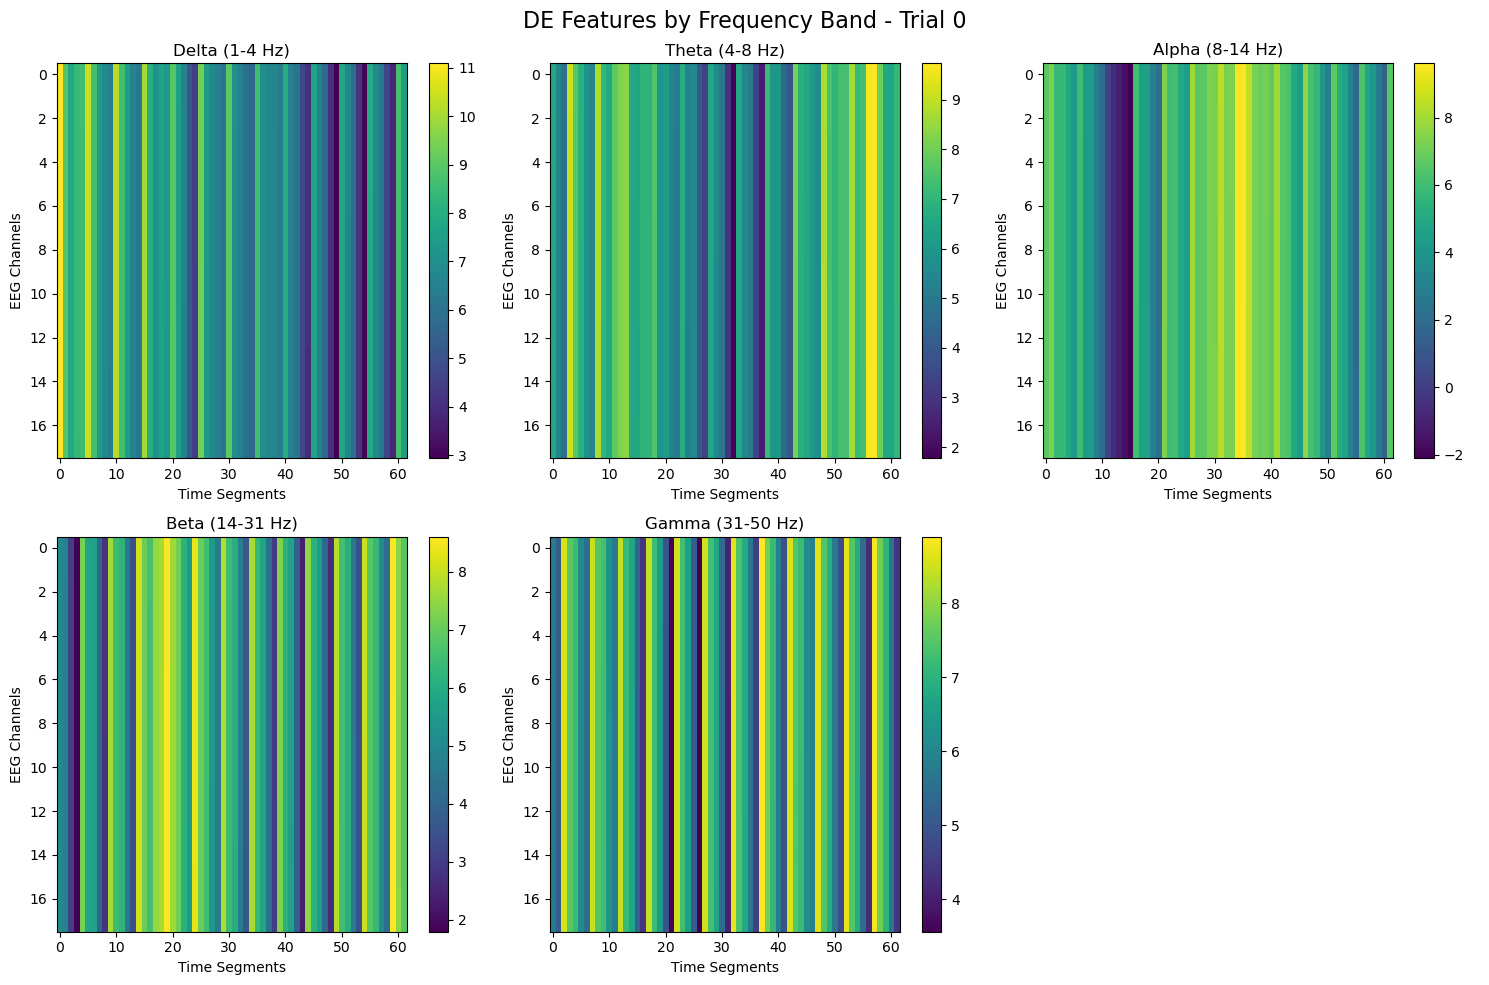

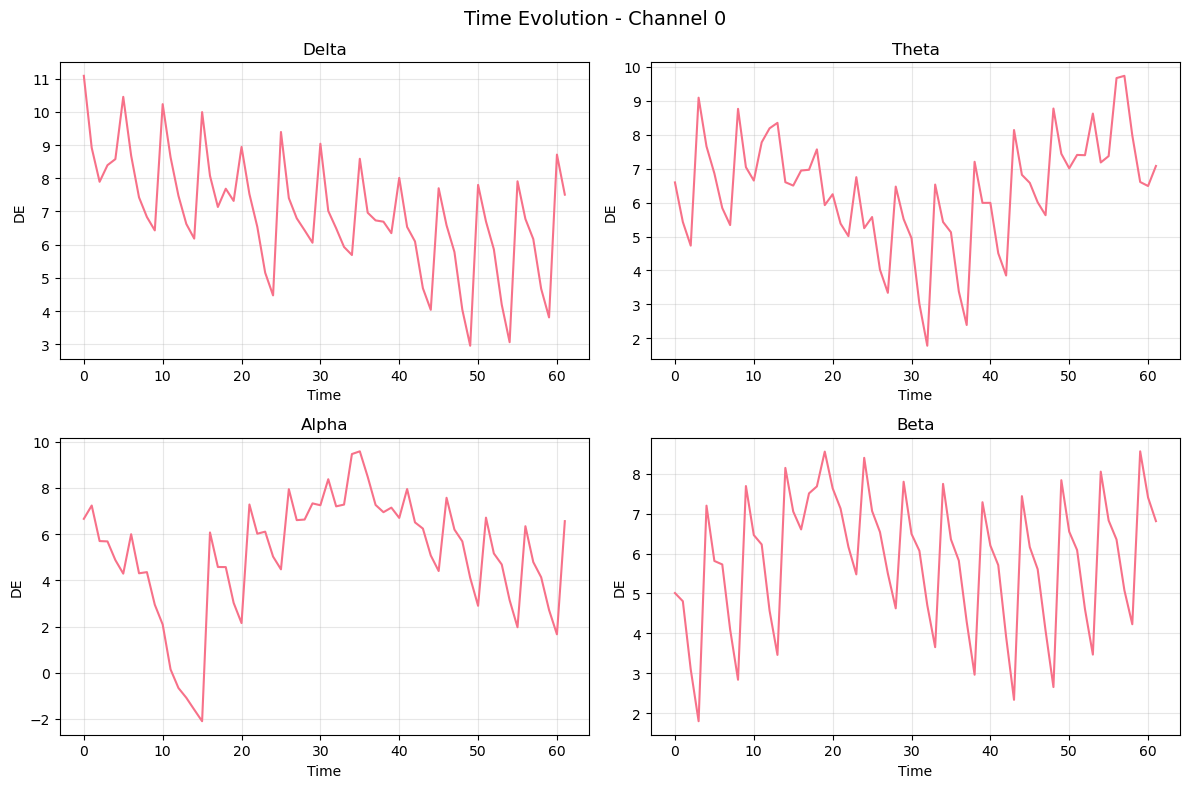

In [ ]:
plt.style.use('default')
sns.set_palette("husl")

# This first visualization shows the spatial distribution of brain activity across diferent frequency bands
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('DE Features by Frequency Band - Trial 0', fontsize=16)

bands = {
    'Delta (1-4 Hz)': delta_band,
    'Theta (4-8 Hz)': theta_band, 
    'Alpha (8-14 Hz)': alpha_band,
    'Beta (14-31 Hz)': beta_band,
    'Gamma (31-50 Hz)': gamma_band
}

# Creating the heatmap for each frequency band
for idx, (band_name, band_data) in enumerate(bands.items()):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    im = ax.imshow(band_data, aspect='auto', cmap='viridis')
    ax.set_title(band_name)
    ax.set_xlabel('Time Segments')  
    ax.set_ylabel('EEG Channels')
    plt.colorbar(im, ax=ax)

axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# The second visualiztion demonstrates the temporal dynamics of main frequency bands for a single channel
fig2, ax_array = plt.subplots(2, 2, figsize=(12, 8))  
fig2.suptitle('Time Evolution - Channel 0', fontsize=14)

main_bands = ['Delta (1-4 Hz)', 'Theta (4-8 Hz)', 'Alpha (8-14 Hz)', 'Beta (14-31 Hz)']
channel_idx = 0

plot_idx = 0
for i in range(2):
    for j in range(2):
        if plot_idx < len(main_bands):
            band_name = main_bands[plot_idx]
            band_data = bands[band_name]
            
            ax_array[i, j].plot(band_data[channel_idx, :], linewidth=1.5)
            ax_array[i, j].set_title(band_name.split(' ')[0])
            ax_array[i, j].set_xlabel('Time')
            ax_array[i, j].set_ylabel('DE')
            ax_array[i, j].grid(alpha=0.3)
            
            plot_idx += 1

plt.tight_layout()
plt.show()

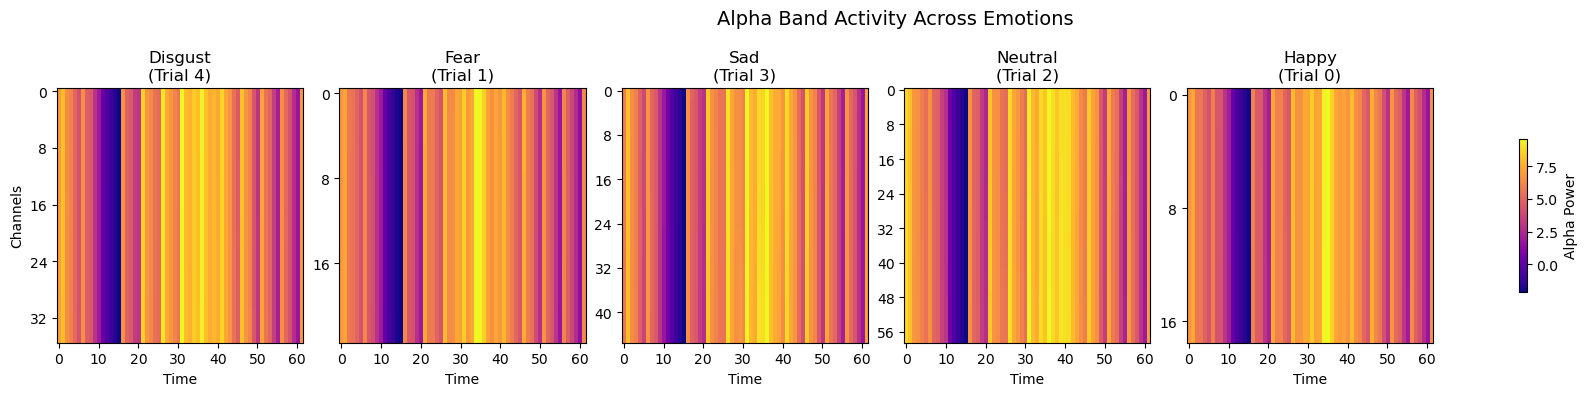

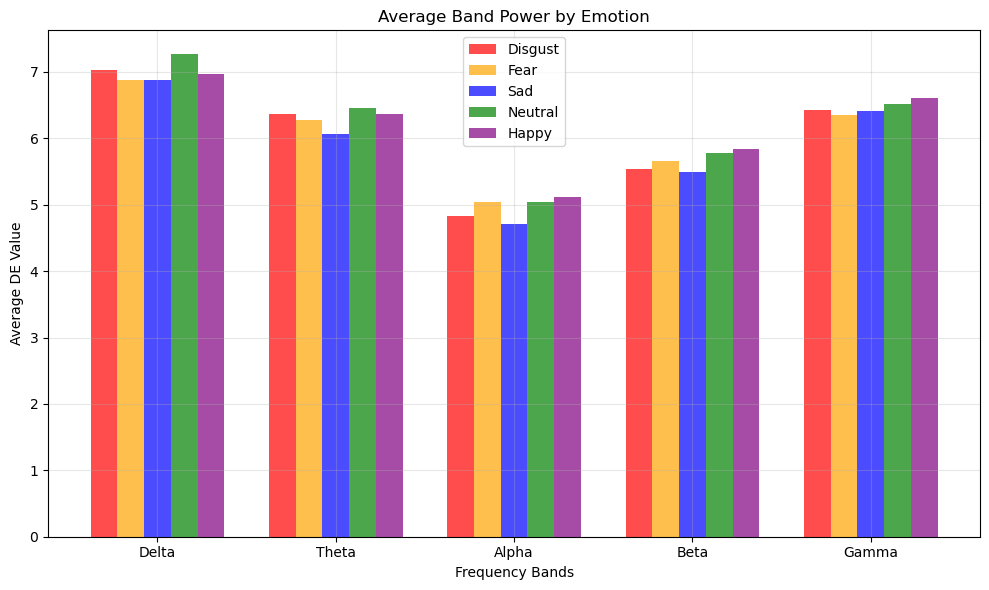

In [ ]:
"""
The first plot shows the 
"""

emotions = ['Disgust', 'Fear', 'Sad', 'Neutral', 'Happy']
band_names = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']
band_ranges = [(0, 62), (62, 124), (124, 186), (186, 248), (248, 310)]

trials_by_emotion = {}
for i in range(45):
    emotion = int(label[i][0])
    if emotion not in trials_by_emotion:
        trials_by_emotion[emotion] = []
    trials_by_emotion[emotion].append(i)

# Plotting on Alpha band for an example. The Alpha band (8-14Hz) is often associated with
# relaxation and emotional processing.
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Alpha Band Activity Across Emotions', fontsize=14)

alpha_start, alpha_end = band_ranges[2]

for i, emotion_idx in enumerate(range(5)):
    ax = axes[i]
    
    if emotion_idx in trials_by_emotion and trials_by_emotion[emotion_idx]:
        trial_num = trials_by_emotion[emotion_idx][0]
        trial_data = data[trial_num]
        alpha_data = trial_data[:, alpha_start:alpha_end]
        
        # This heatmaps aims to show temporal evolution across EEG channels
        im = ax.imshow(alpha_data, aspect='auto', cmap='plasma')
        ax.set_title(f'{emotions[emotion_idx]}\n(Trial {trial_num})')
        ax.set_xlabel('Time')
        
        if i == 0:
            ax.set_ylabel('Channels')
        else:
            ax.set_ylabel('')
            
        ax.set_xticks(range(0, alpha_data.shape[1], 10))
        ax.set_yticks(range(0, alpha_data.shape[0], 8))
    else:
        ax.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(emotions[emotion_idx])

plt.tight_layout()
cbar = fig.colorbar(im, ax=axes, shrink=0.6, aspect=20)
cbar.set_label('Alpha Power')

plt.show()

fig2, ax2 = plt.subplots(figsize=(10, 6))

emotion_means = {}
for emotion_idx in range(5):
    if emotion_idx in trials_by_emotion and trials_by_emotion[emotion_idx]:
        trial_num = trials_by_emotion[emotion_idx][0]
        trial_data = data[trial_num]
        
        band_means = []
        for start, end in band_ranges:
            band_data = trial_data[:, start:end]
            band_means.append(np.mean(band_data))
        
        emotion_means[emotions[emotion_idx]] = band_means

# This grouped bar chart seeks to show which frequency bands are dominant for each emotion
x = np.arange(len(band_names))
width = 0.15

colors = ['red', 'orange', 'blue', 'green', 'purple']
for i, (emotion, means) in enumerate(emotion_means.items()):
    ax2.bar(x + i*width, means, width, label=emotion, color=colors[i], alpha=0.7)

ax2.set_xlabel('Frequency Bands')
ax2.set_ylabel('Average DE Value')
ax2.set_title('Average Band Power by Emotion')
ax2.set_xticks(x + width*2)
ax2.set_xticklabels(band_names)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()